## Gradient boosting regressor

The theory for building a gradient boosting model for regression problems. (Note that for the decision tree and random forest models, we started with a classifier, but here it is actually easier to start with a regressor, as these equations are easier to interpret.) The image below shows some basic terminology and a sketch of a gradient boosting model with many decision trees.

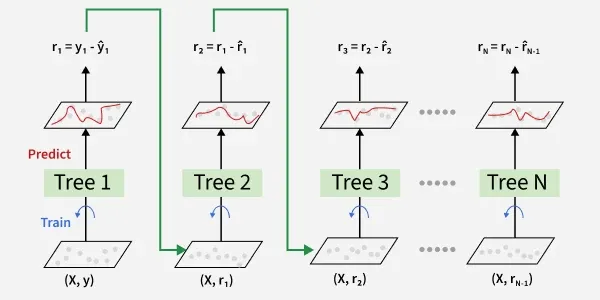

Image from https://www.geeksforgeeks.org/machine-learning/ml-gradient-boosting/

In [1]:
import numpy as np
import pandas as pd

# Add the parent directory to Python's path to import the decision tree
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from decision_tree_regressor_model.decision_tree_regressor import DecisionTreeRegressor

The idea behind a gradient boosting model is to use many "weak learners", i.e. models like decision trees that generally do not achieve great results on their own, to make one strong model. So like the random forest, this is also an ensemble method. It gets a bit more complicated than the random forest model though; where the random forest trains many decision trees separately and then combines the results, the gradient boosting model trains decision trees successively, using the predictions of the previous tree for the next one. We will get into how this works exactly below. The benefit of these gradient-boosted trees is that they generally outperform a random forest. Note that one could use other models than the decision tree for the weak learner as well, but we will only look at the trees.

An essential part of the gradient boosting algorithm is the loss function $L$. This function quantifies how good the predictions of the model are, in the sense that we will seek to minimize this loss function. For regression tasks some choices are the mean squared error (MSE) or the mean absolute error. Here we will only implement the MSE. In that case it is given by

\begin{equation}
\nonumber
    L(y, F(x)) = \frac{1}{N} \sum_{i=1}^N (y_i - F(x_i))^2,
\end{equation}

where $y$ is the target variable, $x$ the training data (forming the dataset $\{(x_i, y_i)\}_{i=1}^N$) and $F(x)$ the prediction of the target variable by a model. So by minimizing this function, the model approaches the true target values.

(Warning: below follows a lot of abstract math. It might help to go back and forth between this section and the one below where we explicitly calculate quantities for the MSE loss function.)

### General algorithm

In order to achieve the minimization of the loss function using our model predictions, we should look at how the loss function varies as a function of our predictions, which naturally brings us to the derivative $\partial L(y_i, F(x_i)) / \partial F(x_i)$. Say we start with some initial predictions $F_0(x)$. Then the gradient (which individually you can just regard as a slope here) $g_i = \partial L(y_i, F(x_i)) / \partial F(x_i) |_{F(x_i)=F_0(x_i)}$ tells us how we should change $F(x_i)$ if we want to move towards the minimum: if it is positive, increasing $F(x_i)$ would increase the loss, and so we should decrease it; vice versa if it is negative. If it is large we still have a long way to go so the increase/decrease of $F(x_i)$ should also be large; the opposite if it is small.

So we want to add to our original model in such a way that we "follow" this gradient. We do this by fitting a decision tree model to these gradients, which predict how much the model needs to be changed, and by then simply adding the predictions of this new decision tree to the original model predictions to get a improved ones. (Note that we cannot simply take the gradients and add those the model, as then we would severely overfit to the training data.) To be specific, we actually fit to the negative gradients, as that moves us towards a minimum instead of a maximum of the loss function (as described above for positive/negative gradients).

With this updated model, we again generate predictions, which give us new gradients $\partial L(y_i, F(x_i)) / \partial F(x_i) |_{F(x_i)=F_{m-1}(x_i)}$ at step $m$. We then fit the following to a decision tree:

\begin{equation}
\nonumber
    r_{im} = -\left. \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right|_{F(x_i)=F_{m-1}(x_i)},
\end{equation}

where $r_{im}$ are called pseudo-residuals (a name that will make sense later), with the negative sign as we have to fit to negative gradients. Thus we fit to the dataset $\{(x_i, r_{im})\}_{i=1}^N$. This process is repeated until the results are good enough, as the predictions move closer to the minimum of the loss function. We will denote the predictions of each new tree as $h_m(x_i)$.

We do however also need an initial prediction to calculate the first residuals with. For this we generally don't use a decision tree, as this could lead to overfitting. Instead, the initial predictions $F_0(x)$ should be chosen such that it is a constant value (the same for each datapoint $x_i$) that minimizes the loss function. So say $F_0(x) = \gamma$, then this value of $\gamma$ should be chosen such that $\partial L(y_i, \gamma) / \partial \gamma = 0$. Once this is known the iteration for training the trees can begin. (A sidenote is that e.g. the Wikipedia page about gradient boosting also mention a factor $\gamma_m$ that is calculated in each step and acts as a weight multiplier. It is however found that this always equals 1, so there is no point in including this. These tests and a more detailed description can be found in the appendix at the bottom of this script.)

However, when adding the predictions of a new tree to the model, we additionally introduce a factor to control this called the learning rate $\nu$. The model predictions at step $m$ can then be written as 

\begin{equation}
\nonumber
    F_m(x) = F_{m-1}(x) + \nu h_m(x).
\end{equation}

This is also called "shrinkage", and improves how well the model can generalize to other data. The learning rate should lie in the interval $0 < \nu \leq 1$, and generally small values like $\nu < 0.1$ should give the best results.

As a final note, it is now clear where the name "gradient boosting" comes from. All of the slopes $g_i$ together form one function that we call the gradient, which shows how the loss function changes in each point, where a point represents the prediction from a model. By using this, we can "boost" the model towards a version where it predicts the values that minimize the loss function.

### Expressions for the MSE loss

Let us then see how these abstract equations work out for our MSE loss function. The pseudo-residuals we fit to are

\begin{equation}
\nonumber
    r_{im} = -\left. \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right|_{F(x_i)=F_{m-1}(x_i)} = -\left. \frac{\partial}{\partial F(x_i)} \frac{1}{N} (y_i - F(x_i))^2 \right|_{F(x_i)=F_{m-1}(x_i)} = \frac{2}{N} (y_i - F_{m-1}(x_i)).
\end{equation}

At step $m$ we know $F_{m-1}$ so that this expression can be evaluated. The most important term here is $(y_i - F_{m-1}(x_i))$, the difference between the target variable and the prediction. This is also known as the residual, explaining why for other loss functions we call $r_{im}$ the pseudo-residual; in this one case the pseudo is actually the real thing. This also helps to understand why fitting a tree to this quantity will improve the model: we are literally checking how far off the target the predictions are, so if we can predict that and add it to the original prediction, we can improve the model. If the model prediction $F_{m-1}$ is too large, the residual is negative, so the new model will subtract something from the original model, bringing it closer to the true value, and vice versa. Also notice how the minus signs cancelled each other; if we had not put a minus sign in front of the derivative, this would not have worked properly.

Now the factor $2/N$ is really just a rescaling of the residuals, and is not adding useful information. The net result of this is that the predictions from the decision tree are also scaled by this factor. Also note how this same factor is applied to every tree, independent of step $m$. Since we are already adding the learning rate $\nu$ as a factor too, we can simply absorb the $2/N$ in there, so the decision trees are fitted to just $(y_i - F_{m-1}(x_i))$. Alternatively, you could also start with a slightly modified loss function (put $1/2$ in front instead of $1/N$) and you end up exactly with this residual; regardless, the model works the same, as the minimization does not depend on overall scaling but only on gradients.

Next, let's calculate the initial predictions. As described we set $F_0(x)=\gamma$ so that $L(y, \gamma) = \frac{1}{N} \sum_{i=1}^N (y_i - \gamma)^2$. Then

\begin{equation}
\nonumber
    \frac{\partial L(y, \gamma)}{\partial \gamma} = \frac{1}{N} \sum_i (-2) (y_i-\gamma) = -\frac{2}{N} \sum_i y_i + \frac{2\gamma}{N} \sum_i 1 = -\frac{2}{N} \sum_i y_i + \frac{2\gamma}{N} \cdot N = -\frac{2}{N} \sum_i y_i + 2\gamma,
\end{equation}

so that $\partial L / \partial \gamma = 0$ gives

\begin{equation}
\nonumber
    \gamma = \frac{1}{N} \sum_i y_i.
\end{equation}

In other words, the loss function is minimal when the initial prediction is the mean of the target variable.

In [2]:
learning_rate = 0.1

def pseudo_residuals(y_true, y_pred):
    """
    Calculate the pseudo-residuals for the MSE loss
    that the decision tree will be fit to, which are
    the actual residuals in this case.

    Parameters:
    y_true (array-like): True values.
    y_pred (array-like): Predicted values.

    Returns:
    array-like: Pseudo-residuals.
    """
    return (y_true - y_pred)

def initial_prediction(y_true):
    """
    Calculate the initial prediction for the gradient 
    boosting algorithm, which is the mean of the 
    target values for the MSE loss.

    Parameters:
    y_true (array-like): True values.

    Returns:
    float: Initial prediction.
    """
    return np.mean(y_true)

### Stochastic gradient boosting

We will add one more element to the model called subsampling. We can then call this a stochastic gradient boosting model. Here we combine gradient boosting with bootstrap aggregating or "bagging", which we have seen before when implementing the random forest model. There, we drew samples with replacement, but here we will do without (meaning data entries only appear once, and the bagged dataset is smaller than the original). Each tree is then trained with a bagged dataset instead of the full one. This increases the performance of the model, as individual trees become less sensitive to noise in the full dataset and the overall model is less likely to get stuck in local minima.

We can use a modified version of the function we used for the random forest to implement this here. The parameter `subsample` can be set to select what fraction of the dataset should be used. Here we only generate one bootstrap sample with the function instead of all at once though, as we need to apply this to the pseudo-residuals that are calculated each step in the loop, so doing it all beforehand is impossible.

Note that while we used a modified version of the decision tree itself as well for the random forest, with more randomness at each step of the tree building, that is not necessary here, because gradient boosting models are already less prone to overfitting. It could still be used of course, and should help to reduce overfitting, but is not as essential as for random forest models, so we will omit it here.

In [ ]:
subsample = 0.8

# Make sure a random seed is defined outside the loops (during initialization of class)
random_state = 42
np.random.seed(random_state)

def create_bootstrap_sample(X, y, subsample):
    """
    Create a bootstrap sample of the given data.
    
    Parameters:
    X (DataFrame): The original dataset.
    y (Series): The labels corresponding to the dataset.
    subsample (float): The fraction of the dataset to be used for the bootstrap sample.
    
    Returns:
    X_sample (DataFrame): The bootstrap sample of the dataset.
    y_sample (Series): The labels corresponding to the bootstrap sample.
    """
    sample_size = int(subsample * len(X))

    # Generate a random sample without replacement
    sample_indices = np.random.choice(sample_size, size=sample_size, replace=False)
    X_sample, y_sample = X.iloc[sample_indices], y.iloc[sample_indices]
    return X_sample, y_sample

Now we can implement the gradient boosting algorithm. A number of hyperparameters are needed here. To start, there are the parameters for the decision trees themselves, as described previously in the decision tree notebook; these are the same for each tree. Next we have the number of trees that are used to train the model, `n_estimators`, just like for the random forest model. Finally, there are the `learning_rate` and `subsample` parameters, which we have already discussed.

To "save" the build model, we return the initial predicted value an a list containing the chain of trees, in the order in which they were fitted. This can then be used to generate predictions from the model.

Finally we also add a scoring function, returning the root mean square error, like we did for the decision tree and random forest regressors.

In [4]:
def build_gradient_booster(X, y, learning_rate, n_estimators, subsample, max_depth=None, min_samples_split=2, 
                           min_samples_leaf=1, verbose=False, threshold=0.0):
    """
    Build a gradient boosting model by fitting a chain of decision trees to the pseudo-residuals.

    Parameters:
    X (DataFrame): The input features.
    y (Series): The target values.
    learning_rate (float): The learning rate for updating predictions.
    n_estimators (int): The number of trees to fit.
    subsample (float): The fraction of the dataset to be used for fitting each tree.

    Returns:
    y_pred_initial (float): The initial prediction for the model.
    tree_chain (list): A list of fitted decision trees in the order they were fitted.
    """
    y_pred_initial = initial_prediction(y)
    
    y_pred_for_residuals = y_pred_initial.copy()
    tree_chain = []
    for _ in range(n_estimators):
        pseudo_residuals_i = pseudo_residuals(y, y_pred_for_residuals)
        X_sample, y_sample = create_bootstrap_sample(X, pseudo_residuals_i, subsample)

        tree = DecisionTreeRegressor(max_depth=max_depth,
                                     min_samples_split=min_samples_split,
                                     min_samples_leaf=min_samples_leaf,
                                     verbose=verbose,
                                     threshold=threshold)
        tree.fit(X_sample, y_sample)
        tree_chain.append(tree)

        # Add current predictions for the residuals in next loop
        y_pred_for_residuals += learning_rate * tree.predict(X)

    return y_pred_initial, tree_chain

def predict(X, y_pred_initial, tree_chain, learning_rate):
    """
    Make predictions using the fitted gradient boosting model.

    Parameters:
    X (DataFrame): The input features for which to make predictions.
    y_pred_initial (float): The initial prediction from the model.
    tree_chain (list): A list of fitted decision trees in the order they were fitted.
    learning_rate (float): The learning rate for updating predictions.

    Returns:
    array-like: The predicted values for the input features.
    """
    y_pred = y_pred_initial.copy()
    for tree in tree_chain:
        y_pred += learning_rate * tree.predict(X)

    return y_pred

def score(y_true, y_pred):
    """
    Calculate the root mean square error of predictions.
    
    Parameters:
    y_true (array-like): True values.
    y_pred (array-like): Predicted values.
    
    Returns:
    float: Root mean square error.
    """
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

Let's then run some tests.

In [6]:
test_data = pd.DataFrame({
    'feature1': [1, 2, 3, 4, 5, 6],
    'feature2': [0, 1, 0, 1, 0, 1],
    'target': [1.1, 1.2, 0.9, 0.1, -0.1, 0.0]
    })
X = test_data[['feature1', 'feature2']]
y = test_data['target']
n_estimators = 20
learning_rate = 0.1
subsample = 1.0

y_pred_initial, tree_chain = build_gradient_booster(X, y, learning_rate, n_estimators, subsample)
predictions = predict(X, y_pred_initial, tree_chain, learning_rate)
print(f"Predictions: {predictions}")
print(f"Score: {score(y, predictions):.4f}")

Predictions: [ 1.03110656  1.1189489   0.85542189  0.15268322 -0.02300145  0.06484088]
Score: 0.0661


In [ ]:
# A more serious test
iris_data = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv', header=None)
X = iris_data.drop(columns=[0])
y = iris_data[0]

# Map the labels to integers
label_mapping = {label: idx for idx, label in enumerate(X[4].unique())}
X[4] = X[4].map(label_mapping)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_estimators = 10
learning_rate = 0.1
subsample = 0.8
y_pred_initial, tree_chain = build_gradient_booster(X_train, y_train, learning_rate, n_estimators, subsample, max_depth=3)
predictions = predict(X_test, y_pred_initial, tree_chain, learning_rate)
print(f"Score: {score(y_test, predictions):.4f}")

Score: 0.3815


In [7]:
learning_rate = 0.1
subsample = 0.8
for n_estimators in [5, 10, 20, 30, 40, 50]:
    y_pred_initial, tree_chain = build_gradient_booster(X_train, y_train, learning_rate, n_estimators, subsample, max_depth=3)
    predictions = predict(X_test, y_pred_initial, tree_chain, learning_rate)
    print(f"n_estimators: {n_estimators}, Score: {score(y_test, predictions):.4f}")

n_estimators: 5, Score: 0.5414
n_estimators: 10, Score: 0.3815
n_estimators: 20, Score: 0.2944
n_estimators: 30, Score: 0.2831
n_estimators: 40, Score: 0.2935
n_estimators: 50, Score: 0.3067


In [8]:
n_estimators = 30
subsample = 0.8
for learning_rate in [0.01, 0.05, 0.1, 0.2]:
    y_pred_initial, tree_chain = build_gradient_booster(X_train, y_train, learning_rate, n_estimators, subsample, max_depth=3)
    predictions = predict(X_test, y_pred_initial, tree_chain, learning_rate)
    print(f"learning_rate: {learning_rate}, Score: {score(y_test, predictions):.4f}")

learning_rate: 0.01, Score: 0.6490
learning_rate: 0.05, Score: 0.3151
learning_rate: 0.1, Score: 0.2831
learning_rate: 0.2, Score: 0.3430


In [9]:
n_estimators = 30
learning_rate = 0.1
for subsample in [0.5, 0.8, 1.0]:
    y_pred_initial, tree_chain = build_gradient_booster(X_train, y_train, learning_rate, n_estimators, subsample, max_depth=3)
    predictions = predict(X_test, y_pred_initial, tree_chain, learning_rate)
    print(f"subsample: {subsample}, Score: {score(y_test, predictions):.4f}")

subsample: 0.5, Score: 0.3282
subsample: 0.8, Score: 0.2831
subsample: 1.0, Score: 0.2882


With these quick tests we get a best score of 0.2882 for 30 estimators, 0.1 learning rate and 1.0 subsample.

One important thing to note is that it helps tremendously, both for the score and runtime, to set the max_depth to 3 instead None like the standard option we set. It might be good to change that, as sklearn also has 3 as the standard value.

In [12]:
# Compare with sklearn's implementation
from sklearn.ensemble import GradientBoostingRegressor
sklearn_gbr = GradientBoostingRegressor(n_estimators=30, learning_rate=0.1, subsample=1.0, random_state=42)
sklearn_gbr.fit(X_train, y_train)
predictions = sklearn_gbr.predict(X_test)
print(f"Score: {score(y_test, predictions):.4f}")

Score: 0.2999


Here we score a bit better than sklearn, but not by that much. sklearn is significantly faster though, running almost instantly instead of the 2 seconds in our implementation.

In [13]:
# Compare with XGBoost
from xgboost import XGBRegressor
xgb_gbr = XGBRegressor(n_estimators=30, learning_rate=0.1, subsample=1.0, random_state=42)
xgb_gbr.fit(X_train, y_train)
predictions = xgb_gbr.predict(X_test)
print(f"Score: {score(y_test, predictions):.4f}")

Score: 0.3185


XGBoost on the other hand scores slightly worse than sklearn, but is also much faster.

In [ ]:
# Diabetes set
from sklearn.datasets import load_diabetes
diabetes_data = load_diabetes()
X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = pd.Series(diabetes_data.target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_estimators = 50
learning_rate = 0.05
subsample = 0.8
y_pred_initial, tree_chain = build_gradient_booster(X_train, y_train, learning_rate, n_estimators, subsample, max_depth=3)
predictions = predict(X_test, y_pred_initial, tree_chain, learning_rate)
print(f"Score: {score(y_test, predictions):.4f}")

Score: 51.7299


In [19]:
sklearn_gbr = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, subsample=0.8, random_state=42)
sklearn_gbr.fit(X_train, y_train)
predictions = sklearn_gbr.predict(X_test)
print(f"Score: {score(y_test, predictions):.4f}")

Score: 52.2298


In [20]:
xgb_gbr = XGBRegressor(n_estimators=50, learning_rate=0.05, subsample=0.8, random_state=42)
xgb_gbr.fit(X_train, y_train)
predictions = xgb_gbr.predict(X_test)
print(f"Score: {score(y_test, predictions):.4f}")

Score: 55.6523


Here we see similar performance, where our implementation is again slightly better than sklearn and a fair bit better than XGBoost. However, where ours takes about 9 seconds to run, the other two are still done pretty much immediately.

In conclusion, you might get slightly better scores with our implementation, but given the importance of speed you are probably still better off with the professional implementations.

### Appendix: weight multiplier $\gamma_m$

In the description of the general algorithm we mentioned the weight multiplier $\gamma_m$ that can be added in each step. Here follows the theoretical description of it.

The idea is that each of step also has to include a weight multiplier, which helps to minimize the loss. The new prediction at each step is written as $F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)$, where $\gamma_m$ is a constant value for this step. After training the new tree so that we know $h_m(x_i)$, this can be calculated such that $L$ is minimal again by choosing it such that $\partial L(y_i, F_m(x_i)) / \partial \gamma_m = 0$.

We can find the weight multipliers $\gamma_m$ similarly to the calculation of the initial predictions: now $F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)$ so that $L(y, F_m(x_i)) = \frac{1}{N} \sum_{i=1}^N (y_i - F_m(x_i))^2 = \frac{1}{N} \sum_{i=1}^N (y_i - F_{m-1}(x_i) - \gamma_m h_m(x_i))^2$. Then 

\begin{equation}
\nonumber
    \frac{\partial L(y, F_m(x_i))}{\partial \gamma_m} = \frac{1}{N} \sum_i (-2 h_m(x_i)) (y_i - F_{m-1}(x_i) - \gamma_m h_m(x_i)) = -\frac{2}{N} \sum_i h_m(x_i) (y_i - F_{m-1}(x_i)) + \frac{2\gamma_m}{N} \sum_i h_m(x_i)^2,
\end{equation}

so that $\partial L / \partial \gamma_m = 0$ gives

\begin{equation}
\nonumber
    \gamma_m \sum_i h_m(x_i)^2 = \sum_i h_m(x_i) (y_i - F_{m-1}(x_i)),
\end{equation}

\begin{equation}
\nonumber
    \gamma_m = \frac{ \sum_i h_m(x_i) (y_i - F_{m-1}(x_i)) }{\sum_i h_m(x_i)^2}.
\end{equation}

The tests below however show that it is always 1, so that there is no reason to include it. Using the learning rate seems like a much more effective method. Additionally, many online explanations simply use the learning rate without even mentioning $\gamma_m$, and it seems like the sklearn implementation also does not use it (https://scikit-learn.org/stable/modules/ensemble.html#shrinkage-via-learning-rate), so we should be fine. I must admit that I cannot mathematically prove that this expression is always 1; the only way is by requiring $h_m(x_i) = (y_i - F_{m-1}(x_i))$ for all $i$, but you can also see below that this is not always the case.

In [5]:
def loss_function(y_true, y_pred):
    # MSE loss
    return np.mean((y_true - y_pred) ** 2)

def weight_multiplier(y_true, y_pred_previous, y_pred_tree):
    # gamma_m
    numerator = np.sum((y_true - y_pred_previous) * y_pred_tree)
    denominator = np.sum(y_pred_tree ** 2)
    return numerator/denominator

In [6]:
# Let's check if the calculations seem correct with some sample data
test_data = pd.DataFrame({
    'feature1': [1, 2, 3, 4, 5, 6, 7, 8],
    'feature2': [0, 1, 0, 1, 0, 1, 0, 1],
    'target': [1.2, 1.1, 1.3, 1.1, 0.1, -0.1, 0.2, 0.0] # for feature1 better
    #'target': [1.2, 0.1, 1.1, -0.1, 1.3, 0.2, 1.1, 0.0] # for feature2 better
    })
X = test_data[['feature1', 'feature2']]
y = test_data['target']

# Initial prediction
y_pred_initial = initial_prediction(y)

# Calculate pseudo-residuals
residuals = pseudo_residuals(y, y_pred_initial)
# Train a decision tree on the residuals
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, residuals)
# Get the predictions from the tree
y_pred_tree = tree.predict(X)
print(f"residuals:\n{residuals}\n tree predictions: {y_pred_tree}")
# Calculate the weight multiplier
gamma = weight_multiplier(y, y_pred_initial, y_pred_tree)
print(f"Multiplier (gamma): {gamma}")
# Calculate the new prediction
y_pred_new = y_pred_initial + gamma * y_pred_tree

# Calculate loss function values
initial_loss = loss_function(y, y_pred_initial)
new_loss = loss_function(y, y_pred_new)
print(f"Initial Loss: {initial_loss}, New Loss: {new_loss}")

# Another step
print()
residuals_2 = pseudo_residuals(y, y_pred_new)
tree_2 = DecisionTreeRegressor(max_depth=3)
tree_2.fit(X, residuals_2)
y_pred_tree_2 = tree_2.predict(X)
print(f"residuals:\n{residuals_2}\n tree predictions: {y_pred_tree_2}")
gamma_2 = weight_multiplier(y, y_pred_new, y_pred_tree_2)
print(f"Multiplier (gamma) for second tree: {gamma_2}")
y_pred_new_2 = y_pred_new + gamma_2 * y_pred_tree_2
new_loss_2 = loss_function(y, y_pred_new_2)
print(f"New Loss after second tree: {new_loss_2}")

residuals:
0    0.5875
1    0.4875
2    0.6875
3    0.4875
4   -0.5125
5   -0.7125
6   -0.4125
7   -0.6125
Name: target, dtype: float64
 tree predictions: [ 0.5875  0.4875  0.6875  0.4875 -0.5125 -0.7125 -0.4125 -0.6125]
Multiplier (gamma): 1.0
Initial Loss: 0.32609375, New Loss: 1.925929944387236e-34

residuals:
0    0.000000e+00
1    0.000000e+00
2    0.000000e+00
3    0.000000e+00
4    2.775558e-17
5   -2.775558e-17
6    0.000000e+00
7    0.000000e+00
Name: target, dtype: float64
 tree predictions: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  2.77555756e-17 -2.77555756e-17  0.00000000e+00  0.00000000e+00]
Multiplier (gamma) for second tree: 1.0
New Loss after second tree: 0.0


In [7]:
# For a more serious dataset
iris_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
iris_data = pd.read_csv(iris_url, header=None)
# Take the first column as target variable for this regression task
X = iris_data.drop(columns=[0])
y = iris_data[0]

# Map the labels to integers
label_mapping = {label: idx for idx, label in enumerate(X[4].unique())}
X[4] = X[4].map(label_mapping)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initial prediction
y_pred_initial = initial_prediction(y_train)
# Calculate pseudo-residuals
residuals = pseudo_residuals(y_train, y_pred_initial)
# Train a decision tree on the residuals
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X_train, residuals)
# Get the predictions from the tree
y_pred_tree = tree.predict(X_train)
print(f"residuals:\n{residuals.values}\n tree predictions: {y_pred_tree}")
print(np.sum(residuals.values*y_pred_tree) / np.sum(y_pred_tree**2))
# Calculate the weight multiplier
gamma = weight_multiplier(y_train, y_pred_initial, y_pred_tree)
print(f"Multiplier (gamma): {gamma}")
# Calculate the new prediction
y_pred_new = y_pred_initial + gamma * y_pred_tree

# Calculate loss function values
initial_loss = loss_function(y_train, y_pred_initial)
new_loss = loss_function(y_train, y_pred_new)
print(f"Initial Loss: {initial_loss}, New Loss: {new_loss}")
# Evaluate on the test set
y_pred_test = y_pred_initial + gamma * tree.predict(X_test)
test_loss = loss_function(y_test, y_pred_test)
print(f"Initial Test Loss: {loss_function(y_test, y_pred_initial)}, New Test Loss: {test_loss}")

# Another step
print()
residuals_2 = pseudo_residuals(y_train, y_pred_new)
tree_2 = DecisionTreeRegressor(max_depth=3)
tree_2.fit(X_train, residuals_2)
y_pred_tree_2 = tree_2.predict(X_train)
print(f"residuals:\n{residuals_2.values}\n tree predictions: {y_pred_tree_2}")
gamma_2 = weight_multiplier(y_train, y_pred_new, y_pred_tree_2)
print(f"Multiplier (gamma) for second tree: {gamma_2}")
y_pred_new_2 = y_pred_new + gamma_2 * y_pred_tree_2
new_loss_2 = loss_function(y_train, y_pred_new_2)
print(f"New Loss after second tree: {new_loss_2}")
# Evaluate on the test set
y_pred_test_2 = y_pred_test + gamma_2 * tree_2.predict(X_test)
test_loss_2 = loss_function(y_test, y_pred_test_2)
print(f"New Test Loss after second tree: {test_loss_2}")

residuals:
[-1.20916667 -0.10916667  0.89083333 -1.00916667 -1.40916667  0.49083333
  0.59083333 -0.60916667 -0.80916667 -0.60916667 -0.00916667  0.19083333
  0.89083333 -0.40916667 -0.40916667 -0.30916667  0.49083333  0.59083333
  0.79083333  1.39083333 -0.10916667  1.79083333 -0.20916667 -0.70916667
  1.89083333 -0.00916667 -0.60916667 -0.80916667 -0.70916667 -0.80916667
  0.49083333 -1.00916667 -0.80916667 -0.70916667 -0.20916667 -0.70916667
 -0.10916667  1.89083333 -1.20916667  0.39083333 -0.10916667 -0.30916667
  0.19083333 -0.00916667  0.19083333 -0.40916667  0.39083333 -0.30916667
 -0.40916667 -0.80916667  0.59083333 -0.80916667 -0.80916667 -0.30916667
  0.89083333 -0.90916667 -0.00916667 -0.80916667 -0.80916667  0.09083333
 -0.70916667  1.09083333  0.19083333  0.29083333  1.89083333 -0.30916667
 -1.40916667 -1.50916667  0.19083333  1.39083333 -1.20916667 -0.70916667
 -1.40916667  0.49083333  0.49083333 -1.20916667  0.99083333  0.49083333
 -1.10916667  0.29083333  0.69083333  0.

In [8]:
# Try diabetes dataset
from sklearn.datasets import load_diabetes
diabetes_data = load_diabetes()
X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = pd.Series(diabetes_data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initial prediction
y_pred_initial = initial_prediction(y_train)
# Calculate pseudo-residuals
residuals = pseudo_residuals(y_train, y_pred_initial)
# Train a decision tree on the residuals
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X_train, residuals)
# Get the predictions from the tree
y_pred_tree = tree.predict(X_train)
# Calculate the weight multiplier
gamma = weight_multiplier(y_train, y_pred_initial, y_pred_tree)
print(f"Multiplier (gamma): {gamma}")
# Calculate the new prediction
y_pred_new = y_pred_initial + gamma * y_pred_tree

# Calculate loss function values
initial_loss = loss_function(y_train, y_pred_initial)
new_loss = loss_function(y_train, y_pred_new)
print(f"Initial Loss: {initial_loss}, New Loss: {new_loss}")
# Evaluate on the test set
y_pred_test = y_pred_initial + gamma * tree.predict(X_test)
test_loss = loss_function(y_test, y_pred_test)
print(f"Initial Test Loss: {loss_function(y_test, y_pred_initial)}, New Test Loss: {test_loss}")

# Another step
residuals_2 = pseudo_residuals(y_train, y_pred_new)
tree_2 = DecisionTreeRegressor(max_depth=3)
tree_2.fit(X_train, residuals_2)
y_pred_tree_2 = tree_2.predict(X_train)
gamma_2 = weight_multiplier(y_train, y_pred_new, y_pred_tree_2)
print(f"Multiplier (gamma) for second tree: {gamma_2}")
y_pred_new_2 = y_pred_new + gamma_2 * y_pred_tree_2
new_loss_2 = loss_function(y_train, y_pred_new_2)
print(f"New Loss after second tree: {new_loss_2}")
# Evaluate on the test set
y_pred_test_2 = y_pred_test + gamma_2 * tree_2.predict(X_test)
test_loss_2 = loss_function(y_test, y_pred_test_2)
print(f"New Test Loss after second tree: {test_loss_2}")

# Another step
residuals_3 = pseudo_residuals(y_train, y_pred_new_2)
tree_3 = DecisionTreeRegressor(max_depth=3)
tree_3.fit(X_train, residuals_3)
y_pred_tree_3 = tree_3.predict(X_train)
gamma_3 = weight_multiplier(y_train, y_pred_new_2, y_pred_tree_3)
print(f"Multiplier (gamma) for third tree: {gamma_3}")
y_pred_new_3 = y_pred_new_2 + gamma_3 * y_pred_tree_3
new_loss_3 = loss_function(y_train, y_pred_new_3)
print(f"New Loss after third tree: {new_loss_3}")
y_pred_test_3 = y_pred_test_2 + gamma_3 * tree_3.predict(X_test)
test_loss_3 = loss_function(y_test, y_pred_test_3)
print(f"New Test Loss after third tree: {test_loss_3}")

# Another step
residuals_4 = pseudo_residuals(y_train, y_pred_new_3)
tree_4 = DecisionTreeRegressor(max_depth=3)
tree_4.fit(X_train, residuals_4)
y_pred_tree_4 = tree_4.predict(X_train)
gamma_4 = weight_multiplier(y_train, y_pred_new_3, y_pred_tree_4)
print(f"Multiplier (gamma) for fourth tree: {gamma_4}")
y_pred_new_4 = y_pred_new_3 + gamma_4 * y_pred_tree_4
new_loss_4 = loss_function(y_train, y_pred_new_4)
print(f"New Loss after fourth tree: {new_loss_4}")
y_pred_test_4 = y_pred_test_3 + gamma_4 * tree_4.predict(X_test)
test_loss_4 = loss_function(y_test, y_pred_test_4)
print(f"New Test Loss after fourth tree: {test_loss_4}")

# Another step
residuals_5 = pseudo_residuals(y_train, y_pred_new_4)
tree_5 = DecisionTreeRegressor(max_depth=3)
tree_5.fit(X_train, residuals_5)
y_pred_tree_5 = tree_5.predict(X_train)
gamma_5 = weight_multiplier(y_train, y_pred_new_4, y_pred_tree_5)
print(f"Multiplier (gamma) for fifth tree: {gamma_5}")
y_pred_new_5 = y_pred_new_4 + gamma_5 * y_pred_tree_5
new_loss_5 = loss_function(y_train, y_pred_new_5)
print(f"New Loss after fifth tree: {new_loss_5}")
y_pred_test_5 = y_pred_test_4 + gamma_5 * tree_5.predict(X_test)
test_loss_5 = loss_function(y_test, y_pred_test_5)
print(f"New Test Loss after fifth tree: {test_loss_5}")
# the loss for the train set keeps going down, but the test loss goes up, and gamma stays just 1

Multiplier (gamma): 1.0
Initial Loss: 6076.398012984615, New Loss: 3106.409580786409
Initial Test Loss: 5361.533457238513, New Test Loss: 3094.965756158935
Multiplier (gamma) for second tree: 1.0000000000000002
New Loss after second tree: 2709.714468580099
New Test Loss after second tree: 3181.500869525771
Multiplier (gamma) for third tree: 1.0
New Loss after third tree: 2483.903176175017
New Test Loss after third tree: 3281.7739163171295
Multiplier (gamma) for fourth tree: 0.9999999999999999
New Loss after fourth tree: 2323.271702180659
New Test Loss after fourth tree: 3445.4658469906176
Multiplier (gamma) for fifth tree: 1.0000000000000002
New Loss after fifth tree: 2209.485767970203
New Test Loss after fifth tree: 3421.085687662261
